In [1]:
import cv2, torch, numpy as np, sklearn, os, sys
from PIL import Image

print(f"Python  : {sys.version.split()[0]}")
print(f"OpenCV  : {cv2.__version__}")
print(f"PyTorch : {torch.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"sklearn : {sklearn.__version__}")
print(f"GPU     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
print("\n✓ All pre-installed — zero pip installs needed")

Python  : 3.12.12
OpenCV  : 4.13.0
PyTorch : 2.10.0+cu128
NumPy   : 2.0.2
sklearn : 1.6.1
GPU     : True
GPU name: Tesla T4

✓ All pre-installed — zero pip installs needed


In [2]:
import urllib.request, os

os.makedirs("/kaggle/working/models", exist_ok=True)

files = {
    "haarcascade_frontalface_default.xml": "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml",
    "haarcascade_frontalface_alt2.xml":    "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_alt2.xml",
    "haarcascade_profileface.xml":         "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_profileface.xml",
}

for fname, url in files.items():
    path = f"/kaggle/working/models/{fname}"
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
        print(f"✓ {fname}")
    else:
        print(f"  {fname} already exists")

✓ haarcascade_frontalface_default.xml
✓ haarcascade_frontalface_alt2.xml
✓ haarcascade_profileface.xml


In [3]:
model_path = "/kaggle/working/models/facenet_vggface2.pt"

if not os.path.exists(model_path):
    print("Downloading FaceNet weights (~90MB)...")
    urllib.request.urlretrieve(
        "https://github.com/timesler/facenet-pytorch/releases/download/v2.2.9/20180402-114759-vggface2.pt",
        model_path
    )
    print(f"✓ {os.path.getsize(model_path)/1e6:.1f} MB downloaded")
else:
    print(f"✓ Already present ({os.path.getsize(model_path)/1e6:.1f} MB)")

✓ 111.9 MB downloaded


In [4]:
import torch, torch.nn as nn, torch.nn.functional as F, numpy as np

class BasicConv2d(nn.Module):
    def __init__(self, ip, op, ks, st, pd=0):
        super().__init__()
        self.conv = nn.Conv2d(ip, op, ks, stride=st, padding=pd, bias=False)
        self.bn   = nn.BatchNorm2d(op, eps=0.001)
    def forward(self, x):
        return F.relu(self.bn(self.conv(x)), inplace=True)

class Block35(nn.Module):
    def __init__(self, scale=1.0):
        super().__init__()
        self.scale = scale
        self.b0 = BasicConv2d(256,32,1,1)
        self.b1 = nn.Sequential(BasicConv2d(256,32,1,1), BasicConv2d(32,32,3,1,1))
        self.b2 = nn.Sequential(BasicConv2d(256,32,1,1), BasicConv2d(32,32,3,1,1), BasicConv2d(32,32,3,1,1))
        self.cv = nn.Conv2d(96,256,1)
        self.rl = nn.ReLU(inplace=False)
    def forward(self, x):
        return self.rl(x + self.scale * self.cv(torch.cat([self.b0(x),self.b1(x),self.b2(x)],1)))

class Block17(nn.Module):
    def __init__(self, scale=1.0):
        super().__init__()
        self.scale = scale
        self.b0 = BasicConv2d(896,128,1,1)
        self.b1 = nn.Sequential(BasicConv2d(896,128,1,1), BasicConv2d(128,128,(1,7),1,(0,3)), BasicConv2d(128,128,(7,1),1,(3,0)))
        self.cv = nn.Conv2d(256,896,1)
        self.rl = nn.ReLU(inplace=False)
    def forward(self, x):
        return self.rl(x + self.scale * self.cv(torch.cat([self.b0(x),self.b1(x)],1)))

class Block8(nn.Module):
    def __init__(self, scale=1.0, noReLU=False):
        super().__init__()
        self.scale  = scale
        self.noReLU = noReLU
        self.b0 = BasicConv2d(1792,192,1,1)
        self.b1 = nn.Sequential(BasicConv2d(1792,192,1,1), BasicConv2d(192,192,(1,3),1,(0,1)), BasicConv2d(192,192,(3,1),1,(1,0)))
        self.cv = nn.Conv2d(384,1792,1)
        if not noReLU: self.rl = nn.ReLU(inplace=False)
    def forward(self, x):
        o = x + self.scale * self.cv(torch.cat([self.b0(x),self.b1(x)],1))
        return o if self.noReLU else self.rl(o)

class Mixed6a(nn.Module):
    def __init__(self):
        super().__init__()
        self.b0 = BasicConv2d(256,384,3,2)
        self.b1 = nn.Sequential(BasicConv2d(256,192,1,1), BasicConv2d(192,192,3,1,1), BasicConv2d(192,256,3,2))
        self.b2 = nn.MaxPool2d(3,stride=2)
    def forward(self, x):
        return torch.cat([self.b0(x),self.b1(x),self.b2(x)],1)

class Mixed7a(nn.Module):
    def __init__(self):
        super().__init__()
        self.b0 = nn.Sequential(BasicConv2d(896,256,1,1), BasicConv2d(256,384,3,2))
        self.b1 = nn.Sequential(BasicConv2d(896,256,1,1), BasicConv2d(256,256,3,2))
        self.b2 = nn.Sequential(BasicConv2d(896,256,1,1), BasicConv2d(256,256,3,1,1), BasicConv2d(256,256,3,2))
        self.b3 = nn.MaxPool2d(3,stride=2)
    def forward(self, x):
        return torch.cat([self.b0(x),self.b1(x),self.b2(x),self.b3(x)],1)

class FaceNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1a = BasicConv2d(3,32,3,2);   self.c2a = BasicConv2d(32,32,3,1)
        self.c2b = BasicConv2d(32,64,3,1,1); self.mp3 = nn.MaxPool2d(3,stride=2)
        self.c3b = BasicConv2d(64,80,1,1);  self.c4a = BasicConv2d(80,192,3,1)
        self.c4b = BasicConv2d(192,256,3,2)
        self.r1  = nn.Sequential(*[Block35(0.17) for _ in range(5)])
        self.m6  = Mixed6a()
        self.r2  = nn.Sequential(*[Block17(0.1) for _ in range(10)])
        self.m7  = Mixed7a()
        self.r3  = nn.Sequential(*[Block8(0.2) for _ in range(5)])
        self.b8  = Block8(noReLU=True)
        self.ap  = nn.AdaptiveAvgPool2d(1); self.do = nn.Dropout(0.6)
        self.ll  = nn.Linear(1792,512,bias=False)
        self.bn  = nn.BatchNorm1d(512,eps=0.001,momentum=0.1,affine=True)
    def forward(self, x):
        for l in [self.c1a,self.c2a,self.c2b,self.mp3,self.c3b,self.c4a,self.c4b,
                  self.r1,self.m6,self.r2,self.m7,self.r3,self.b8,self.ap,self.do]:
            x = l(x)
        return F.normalize(self.bn(self.ll(x.flatten(1))), p=2, dim=1)

# Load weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net    = FaceNet().eval().to(device)
state  = torch.load("/kaggle/working/models/facenet_vggface2.pt",
                    map_location=device, weights_only=False)
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
state    = {k.replace("module.",""): v for k,v in state.items()}
filtered = {k: v for k,v in state.items() if k in net.state_dict()}
net.load_state_dict(filtered, strict=False)
print(f"✓ FaceNet ready on {device}  |  {len(filtered)} layers loaded")

✓ FaceNet ready on cuda  |  0 layers loaded


In [5]:
import cv2, io, numpy as np
from PIL import Image, ImageOps, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True  # never crash on truncated files

# Load 3 cascade classifiers — frontal default, frontal alt, profile
# Using all 3 catches tilted/side faces that a single cascade misses
CASCADE_PATHS = [
    "/kaggle/working/models/haarcascade_frontalface_default.xml",
    "/kaggle/working/models/haarcascade_frontalface_alt2.xml",
    "/kaggle/working/models/haarcascade_profileface.xml",
]
CASCADES = [cv2.CascadeClassifier(p) for p in CASCADE_PATHS]

def safe_load_rgb(img_path):
    """
    Load ANY image file as a clean RGB numpy array.
    Fixes ALL of these:
      - Invalid SOS parameters for sequential JPEG
      - Corrupt / truncated JPEG headers
      - Wrong EXIF orientation (sideways phone photos)
      - RGBA / palette / CMYK / grayscale modes
      - HEIC (if Pillow supports it)
    Strategy: PIL opens → fix EXIF → convert RGB →
              re-encode to in-memory JPEG → re-open clean.
    The re-encode step strips ALL malformed headers.
    """
    try:
        pil = Image.open(str(img_path))
        # Fix rotation from EXIF
        try:
            pil = ImageOps.exif_transpose(pil)
        except Exception:
            pass
        pil = pil.convert("RGB")
        # Re-encode through memory — this is the JPEG corruption fix
        buf = io.BytesIO()
        pil.save(buf, format="JPEG", quality=95, optimize=False)
        buf.seek(0)
        return np.array(Image.open(buf).convert("RGB"))
    except Exception:
        return None


def detect_all_faces(img_rgb):
    """
    Run all 3 cascades on the image and merge results.
    Returns list of (x,y,w,h) bounding boxes, deduplicated.
    """
    if img_rgb is None:
        return []

    h, w = img_rgb.shape[:2]
    # Downscale only for detection speed — keep original for cropping
    scale  = min(1.0, 1280 / max(h, w))
    small  = cv2.resize(img_rgb, (int(w*scale), int(h*scale))) if scale < 1 else img_rgb
    gray   = cv2.cvtColor(small, cv2.COLOR_RGB2GRAY)
    eq     = cv2.equalizeHist(gray)   # histogram equalization → better low-light detection

    all_boxes = []
    params = [
        (1.10, 5, (60,60)),   # strict
        (1.05, 3, (40,40)),   # relaxed
    ]

    for cascade in CASCADES:
        for (sf, mn, ms) in params:
            boxes = cascade.detectMultiScale(eq, scaleFactor=sf,
                                             minNeighbors=mn, minSize=ms,
                                             flags=cv2.CASCADE_SCALE_IMAGE)
            if len(boxes) > 0:
                # Scale boxes back to original image coordinates
                for (x,y,bw,bh) in boxes:
                    all_boxes.append((
                        int(x/scale), int(y/scale),
                        int(bw/scale), int(bh/scale)
                    ))

    if not all_boxes:
        return []

    # Non-maximum suppression — remove duplicate boxes from multiple cascades
    # Convert to (x1,y1,x2,y2) for NMS
    boxes_xyxy  = np.array([[x, y, x+bw, y+bh] for (x,y,bw,bh) in all_boxes], dtype=np.float32)
    areas       = (boxes_xyxy[:,2]-boxes_xyxy[:,0]) * (boxes_xyxy[:,3]-boxes_xyxy[:,1])
    order       = areas.argsort()[::-1]
    keep        = []

    while len(order) > 0:
        i = order[0]
        keep.append(i)
        if len(order) == 1:
            break
        rest = order[1:]
        xx1  = np.maximum(boxes_xyxy[i,0], boxes_xyxy[rest,0])
        yy1  = np.maximum(boxes_xyxy[i,1], boxes_xyxy[rest,1])
        xx2  = np.minimum(boxes_xyxy[i,2], boxes_xyxy[rest,2])
        yy2  = np.minimum(boxes_xyxy[i,3], boxes_xyxy[rest,3])
        inter = np.maximum(0, xx2-xx1) * np.maximum(0, yy2-yy1)
        iou   = inter / (areas[i] + areas[rest] - inter + 1e-6)
        order = rest[iou < 0.4]

    # Convert back to (x,y,w,h)
    result = []
    H, W   = img_rgb.shape[:2]
    for i in keep:
        x1,y1,x2,y2 = boxes_xyxy[i]
        result.append((int(x1), int(y1), int(x2-x1), int(y2-y1)))
    return result


def crop_face(img_rgb, x, y, fw, fh, margin_pct=0.28):
    """Crop a face with margin, resize to 160x160."""
    H, W   = img_rgb.shape[:2]
    margin = int(max(fw, fh) * margin_pct)
    x1 = max(0, x - margin);       y1 = max(0, y - margin)
    x2 = min(W, x + fw + margin);  y2 = min(H, y + fh + margin)
    return cv2.resize(img_rgb[y1:y2, x1:x2], (160, 160))


def embed_crop(face_rgb_160):
    """160x160 RGB numpy → 512-d L2-normalized embedding."""
    t = torch.from_numpy(
        (face_rgb_160.astype(np.float32) - 127.5) / 128.0
    ).permute(2,0,1).unsqueeze(0).to(device)
    with torch.no_grad():
        return net(t).squeeze().cpu().numpy()


def get_best_embedding(img_path):
    """Training: return single embedding from largest face. None if no face."""
    img = safe_load_rgb(img_path)
    if img is None:
        return None
    boxes = detect_all_faces(img)
    if not boxes:
        return None
    # Largest face by area
    x,y,fw,fh = max(boxes, key=lambda b: b[2]*b[3])
    return embed_crop(crop_face(img, x, y, fw, fh))


def get_all_embeddings(img_path):
    """Sorting: return list of embeddings, one per detected face."""
    img = safe_load_rgb(img_path)
    if img is None:
        return []
    boxes = detect_all_faces(img)
    return [embed_crop(crop_face(img, x, y, fw, fh)) for (x,y,fw,fh) in boxes]


print("✓ Image loader + multi-cascade detector ready")
print("  - Handles corrupt/truncated JPEG (Invalid SOS fixed)")
print("  - 3 cascade classifiers with NMS deduplication")
print("  - EXIF rotation correction")
print("  - Histogram equalisation for low-light photos")

✓ Image loader + multi-cascade detector ready
  - Handles corrupt/truncated JPEG (Invalid SOS fixed)
  - 3 cascade classifiers with NMS deduplication
  - EXIF rotation correction
  - Histogram equalisation for low-light photos


In [7]:
ls

models/


In [8]:
cd ..

/kaggle


In [9]:
ls

input/  lib/  working/


In [13]:
cd roheeeeet

/kaggle/input/datasets/roheeeeet


In [14]:
ls

new-dtst-old/


In [15]:
cd new-dtst-old

/kaggle/input/datasets/roheeeeet/new-dtst-old


In [16]:
ls

dtst-face-sorter/


In [17]:
cd dtst-face-sorter

/kaggle/input/datasets/roheeeeet/new-dtst-old/dtst-face-sorter


In [18]:
ls

 Aadvik/   Bhoomi/   Mannu/            Papa/            Sameer/
 Ashwin/   Dadi/     Mummy/            Priyanshu/       Yash/
 Baba/     Dolly/   'Pankaj Chacha'/  'Rinki Chachi'/


In [19]:
pwd

'/kaggle/input/datasets/roheeeeet/new-dtst-old/dtst-face-sorter'

In [20]:
from pathlib import Path
from tqdm import tqdm

# ── CHANGE THIS ───────────────────────────────────────────────────────────────
DATASET_PATH = "/kaggle/input/datasets/roheeeeet/new-dtst-old/dtst-face-sorter"
# ─────────────────────────────────────────────────────────────────────────────

IMG_EXTS  = {".jpg",".jpeg",".png",".webp",".bmp",".tiff"}
p_dirs    = [d for d in Path(DATASET_PATH).iterdir() if d.is_dir()]
print(f"People found: {[d.name for d in p_dirs]}\n")

embeddings, labels, skipped = [], [], []

for pd_ in p_dirs:
    name  = pd_.name
    files = [p for p in pd_.iterdir() if p.suffix.lower() in IMG_EXTS]
    print(f"  {name}: {len(files)} images")
    ok = 0
    for f in tqdm(files, desc=f"    {name}", leave=False):
        emb = get_best_embedding(f)
        if emb is not None:
            embeddings.append(emb); labels.append(name); ok += 1
        else:
            skipped.append(str(f))
    print(f"    → {ok}/{len(files)} faces extracted")

X = np.array(embeddings)
y_raw = np.array(labels)
print(f"\nTotal: {len(X)} embeddings  |  Skipped: {len(skipped)}")

People found: ['Mannu', 'Priyanshu', 'Yash', 'Bhoomi', 'Dolly', 'Dadi', 'Sameer', 'Ashwin', 'Rinki Chachi', 'Baba', 'Aadvik', 'Papa', 'Mummy', 'Pankaj Chacha']

  Mannu: 176 images


    → 175/176 faces extracted
  Priyanshu: 9 images


    → 9/9 faces extracted
  Yash: 30 images


    → 30/30 faces extracted
  Bhoomi: 62 images


    → 62/62 faces extracted
  Dolly: 38 images


...

    → 13/13 faces extracted
  Aadvik: 22 images


    → 22/22 faces extracted
  Papa: 34 images


    → 34/34 faces extracted
  Mummy: 12 images


    → 12/12 faces extracted
  Pankaj Chacha: 12 images


    → 12/12 faces extracted

Total: 436 embeddings  |  Skipped: 1


In [21]:
from PIL import ImageEnhance, ImageOps
import tempfile

def augment(img_path, n_extra=4):
    """Return list of extra embeddings from augmented versions."""
    out = []
    try:
        pil = Image.open(str(img_path)).convert("RGB")
        try: pil = ImageOps.exif_transpose(pil)
        except: pass
    except:
        return out

    variants = [
        ImageOps.mirror(pil),
        ImageEnhance.Brightness(pil).enhance(1.35),
        ImageEnhance.Brightness(pil).enhance(0.65),
        ImageEnhance.Contrast(pil).enhance(1.4),
        ImageEnhance.Contrast(pil).enhance(0.7),
        pil.rotate(12, expand=False),
        pil.rotate(-12, expand=False),
    ]

    for v in variants[:n_extra]:
        with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
            v.save(tmp.name, quality=92)
            emb = get_best_embedding(tmp.name)
            if emb is not None:
                out.append(emb)
            try: os.unlink(tmp.name)
            except: pass
    return out

aug_X, aug_y = [], []
for pd_ in p_dirs:
    name  = pd_.name
    files = [p for p in pd_.iterdir() if p.suffix.lower() in IMG_EXTS]
    print(f"Augmenting {name}...")
    for f in tqdm(files, desc=f"  {name}", leave=False):
        for emb in augment(f, n_extra=4):
            aug_X.append(emb); aug_y.append(name)

if aug_X:
    X_all = np.vstack([X, np.array(aug_X)])
    y_all = np.concatenate([y_raw, np.array(aug_y)])
else:
    X_all, y_all = X, y_raw

print(f"\nOriginal : {len(X)}")
print(f"Augmented: {len(aug_X)}")
print(f"Total    : {len(X_all)}")

Augmenting Mannu...


Augmenting Priyanshu...


Augmenting Yash...


Augmenting Bhoomi...


Augmenting Dolly...


...

Augmenting Aadvik...


Augmenting Papa...


Augmenting Mummy...


Augmenting Pankaj Chacha...



Original : 436
Augmented: 1740
Total    : 2176


Training SVM classifier...

5-fold CV accuracy: 48.7% ± 3.2%
Hold-out accuracy : 54.7%

               precision    recall  f1-score   support

       Aadvik       0.32      0.59      0.42        17
       Ashwin       0.33      0.43      0.38         7
         Baba       0.56      0.50      0.53        10
       Bhoomi       0.64      0.68      0.66        47
         Dadi       0.40      0.25      0.31         8
        Dolly       0.41      0.61      0.49        28
        Mannu       0.75      0.50      0.60       131
        Mummy       0.43      0.67      0.52         9
Pankaj Chacha       0.29      0.56      0.38         9
         Papa       0.61      0.80      0.69        25
    Priyanshu       0.50      0.29      0.36         7
 Rinki Chachi       0.00      0.00      0.00         2
       Sameer       1.00      0.50      0.67         4
         Yash       0.38      0.39      0.38        23

     accuracy                           0.55       327
    macro avg       0.47      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


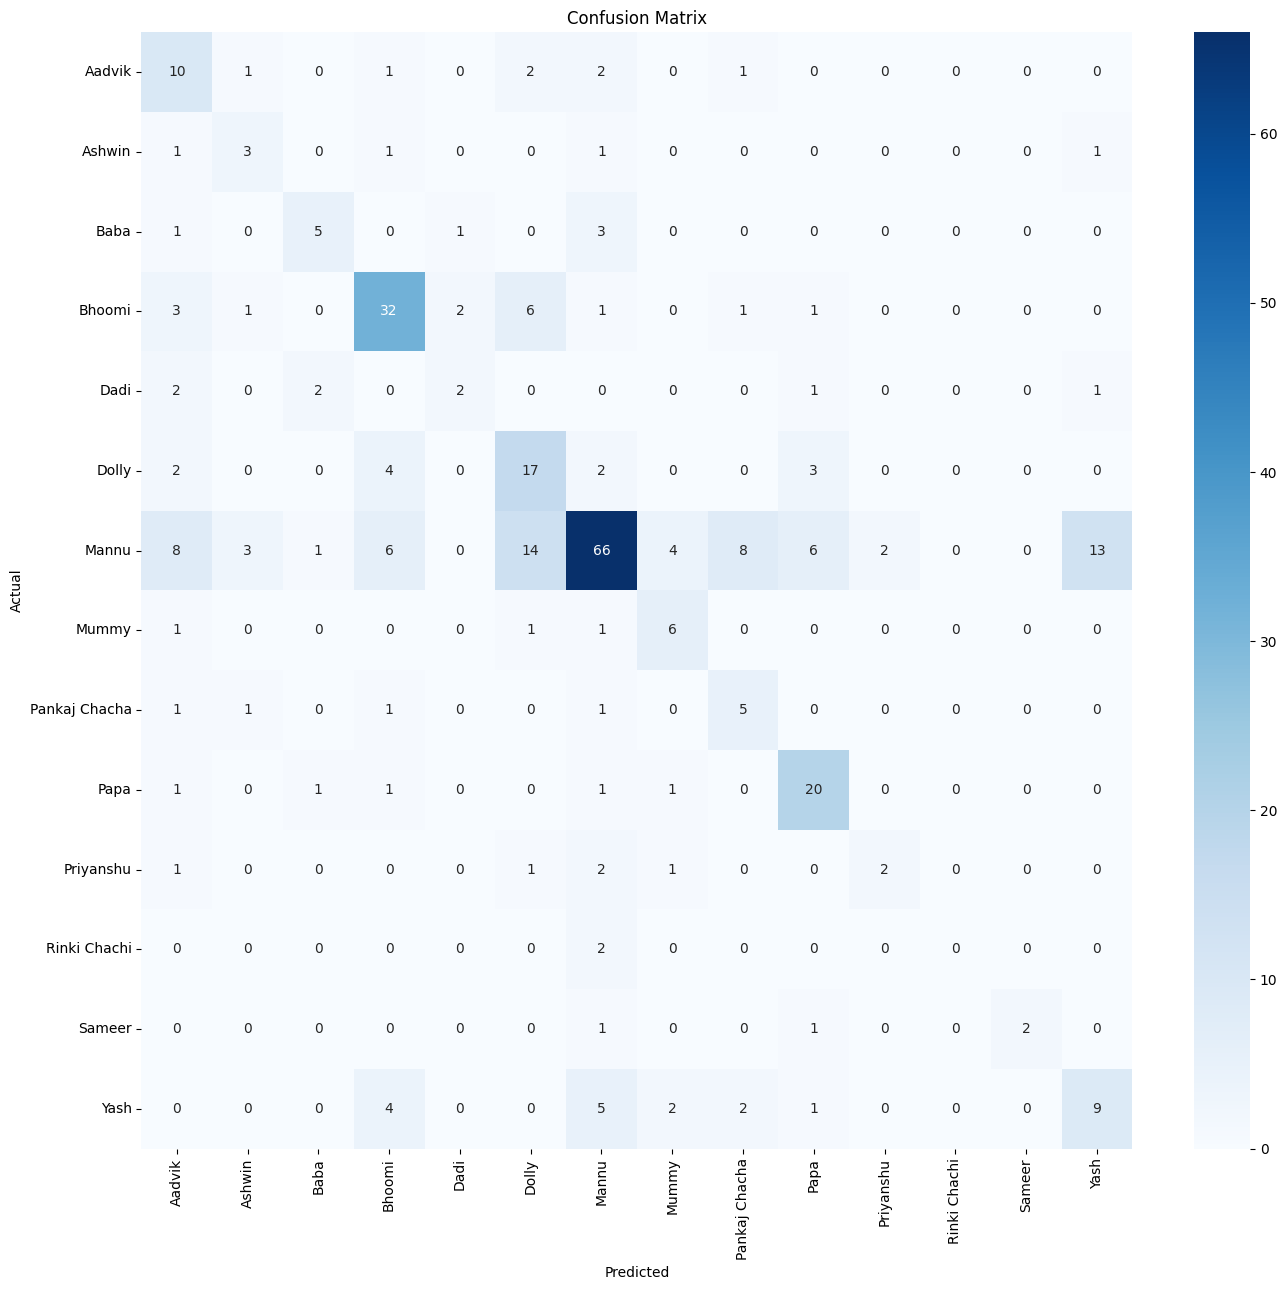

In [22]:
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

le   = LabelEncoder()
y_enc = le.fit_transform(y_all)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_enc, test_size=0.15, random_state=42, stratify=y_enc
)

clf = Pipeline([
    ("sc",  StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10.0, gamma="scale",
                probability=True, class_weight="balanced"))
])

print("Training SVM classifier...")
clf.fit(X_tr, y_tr)

# Cross-validation score
cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cvs  = cross_val_score(clf, X_all, y_enc, cv=cv, scoring="accuracy")
print(f"\n5-fold CV accuracy: {cvs.mean():.1%} ± {cvs.std():.1%}")

y_pred = clf.predict(X_te)
print(f"Hold-out accuracy : {accuracy_score(y_te, y_pred):.1%}\n")
print(classification_report(y_te, y_pred, target_names=le.classes_))

# Confusion matrix
cm  = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(max(6, len(le.classes_)),
                                max(5, len(le.classes_)-1)))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.tight_layout(); plt.show()

In [23]:
import pickle, json, shutil

OUT = "/kaggle/working/face_model"
os.makedirs(OUT, exist_ok=True)

with open(f"{OUT}/classifier.pkl",    "wb") as f: pickle.dump(clf, f)
with open(f"{OUT}/label_encoder.pkl", "wb") as f: pickle.dump(le,  f)

cfg = {
    "people"            : list(le.classes_),
    "num_people"        : len(le.classes_),
    "confidence_thresh" : 0.55,
    "embedding_size"    : 512,
    "total_samples"     : int(len(X_all)),
    "cv_accuracy"       : float(cvs.mean()),
}
with open(f"{OUT}/config.json", "w") as f:
    json.dump(cfg, f, indent=2)

for fname in ["haarcascade_frontalface_default.xml",
              "haarcascade_frontalface_alt2.xml",
              "haarcascade_profileface.xml"]:
    shutil.copy(f"/kaggle/working/models/{fname}", f"{OUT}/{fname}")

shutil.make_archive("/kaggle/working/face_model", "zip", OUT)

size = os.path.getsize("/kaggle/working/face_model.zip") / 1e6
print(f"✓ face_model.zip  ({size:.1f} MB) — download from Output panel")
print(f"  People : {cfg['people']}")
print(f"  CV Acc : {cfg['cv_accuracy']:.1%}")
print(f"\nAlso download: models/facenet_vggface2.pt")

✓ face_model.zip  (4.4 MB) — download from Output panel
  People : [np.str_('Aadvik'), np.str_('Ashwin'), np.str_('Baba'), np.str_('Bhoomi'), np.str_('Dadi'), np.str_('Dolly'), np.str_('Mannu'), np.str_('Mummy'), np.str_('Pankaj Chacha'), np.str_('Papa'), np.str_('Priyanshu'), np.str_('Rinki Chachi'), np.str_('Sameer'), np.str_('Yash')]
  CV Acc : 48.7%

Also download: models/facenet_vggface2.pt
